In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/players_features.csv')

CLUSTER_FEATURES = [
    'goals_per90', 'assists_per90', 'gc_per90',
    'yellow_per90', 'minutes_ratio', 'market_value_log',
    'pos_Attack', 'pos_Midfield', 'pos_Defender', 'pos_Goalkeeper'
]

X = df[CLUSTER_FEATURES].fillna(0)
print(f"Feature matrix: {X.shape[0]} players x {X.shape[1]} features")

Feature matrix: 25088 players x 10 features


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — goals_per90 range:")
print(f"  min: {X['goals_per90'].min():.3f}, max: {X['goals_per90'].max():.3f}")

print("\nAfter scaling — goals_per90 range:")
print(f"  min: {X_scaled[:,0].min():.3f}, max: {X_scaled[:,0].max():.3f}")

Before scaling — goals_per90 range:
  min: 0.000, max: 0.709

After scaling — goals_per90 range:
  min: -0.715, max: 3.966


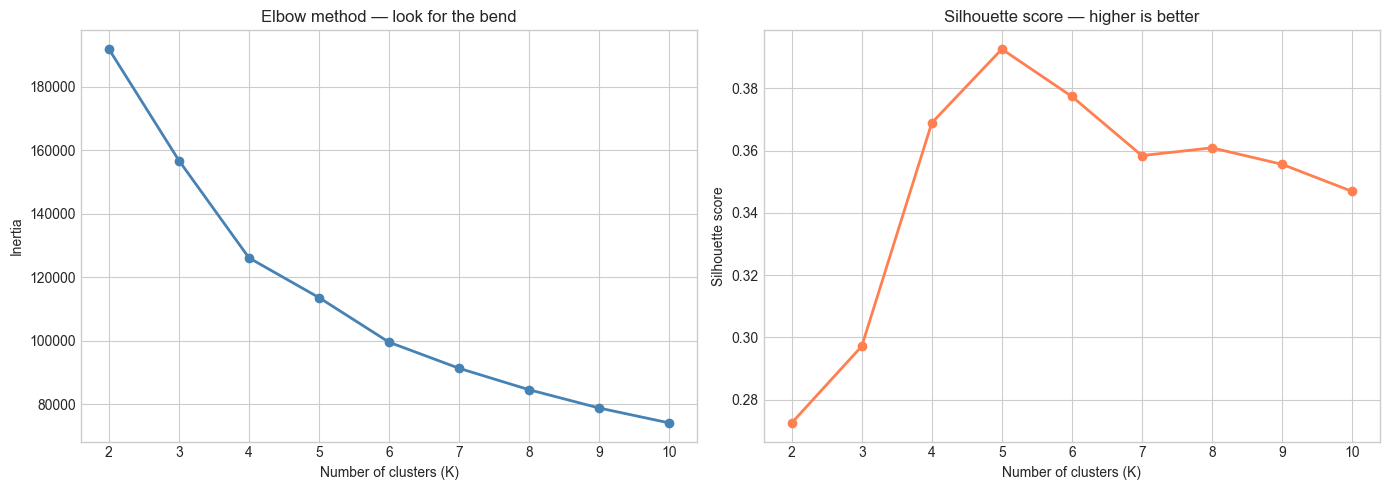

In [3]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow method — look for the bend')

ax2.plot(K_range, silhouettes, marker='o', color='coral', linewidth=2)
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score — higher is better')

plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
K_BEST = 4

km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Players per cluster:")
print(df['cluster'].value_counts().sort_index())

print("\nPosition breakdown per cluster:")
print(pd.crosstab(df['cluster'], df['position']))

Players per cluster:
cluster
0    2233
1    6434
2    7120
3    9301
Name: count, dtype: int64

Position breakdown per cluster:
position  Attack  Defender  Goalkeeper  Midfield  Missing
cluster                                                  
0              0         0        2233         0        0
1           6166        75           0       186        7
2              0         0           0      7117        3
3            991      8276           0         0       34


In [5]:
cluster_profiles = df.groupby('cluster')[
    ['goals_per90','assists_per90','yellow_per90',
     'minutes_ratio','market_value_in_eur']
].mean().round(3)

print(cluster_profiles)
print("\nTop 3 sub-positions per cluster:")
for c in range(K_BEST):
    top = df[df['cluster']==c]['sub_position'].value_counts().head(3)
    print(f"\nCluster {c}: {top.index.tolist()}")

         goals_per90  assists_per90  yellow_per90  minutes_ratio  \
cluster                                                            
0              0.000          0.002         0.060          0.097   
1              0.285          0.161         0.190          0.088   
2              0.084          0.091         0.246          0.098   
3              0.030          0.040         0.218          0.097   

         market_value_in_eur  
cluster                       
0                1196065.197  
1                2964538.279  
2                2305082.343  
3                1842334.916  

Top 3 sub-positions per cluster:

Cluster 0: ['Goalkeeper']

Cluster 1: ['Centre-Forward', 'Left Winger', 'Right Winger']

Cluster 2: ['Central Midfield', 'Defensive Midfield', 'Attacking Midfield']

Cluster 3: ['Centre-Back', 'Right-Back', 'Left-Back']


In [6]:
cluster_names = {
    0: 'Goalkeeper',
    1: 'Forward',
    2: 'Midfielder',
    3: 'Defender',
}

df['playstyle'] = df['cluster'].map(cluster_names)
print(df['playstyle'].value_counts())

playstyle
Defender      9301
Midfielder    7120
Forward       6434
Goalkeeper    2233
Name: count, dtype: int64


Variance explained by 2 components: 45.4%


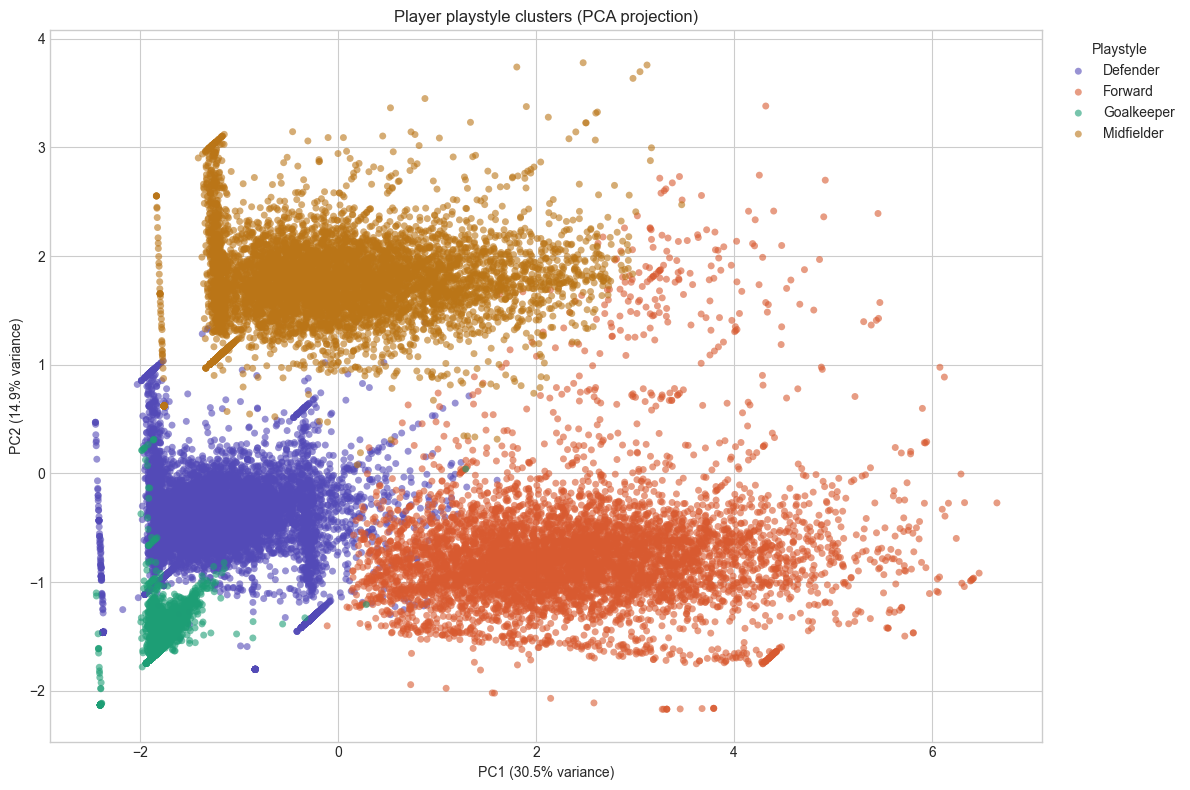

In [7]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

print(f"Variance explained by 2 components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#534AB7','#D85A30','#1D9E75','#BA7517','#D4537E']

for i, (name, group) in enumerate(df.groupby('playstyle')):
    ax.scatter(group['pca_x'], group['pca_y'],
               label=name, alpha=0.6, s=25,
               color=colors[i % len(colors)],
               edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Player playstyle clusters (PCA projection)')
ax.legend(title='Playstyle', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=== Cluster sanity check ===")
for playstyle, grp in df.groupby('playstyle'):
    print(f"\n{playstyle} ({len(grp)} players)")
    print(f"  Avg goals/90:   {grp['goals_per90'].mean():.3f}")
    print(f"  Avg assists/90: {grp['assists_per90'].mean():.3f}")
    print(f"  Avg yellow/90:  {grp['yellow_per90'].mean():.3f}")
    top5 = grp.nlargest(3,'market_value_in_eur')[['name','market_value_in_eur']].values
    print(f"  Top players:    {[r[0] for r in top5]}")

=== Cluster sanity check ===

Defender (9301 players)
  Avg goals/90:   0.030
  Avg assists/90: 0.040
  Avg yellow/90:  0.218
  Top players:    ['William Saliba', 'Achraf Hakimi', 'Pau Cubarsí']

Forward (6434 players)
  Avg goals/90:   0.285
  Avg assists/90: 0.161
  Avg yellow/90:  0.190
  Top players:    ['Kylian Mbappé', 'Erling Haaland', 'Lamine Yamal']

Goalkeeper (2233 players)
  Avg goals/90:   0.000
  Avg assists/90: 0.002
  Avg yellow/90:  0.060
  Top players:    ['Gianluigi Donnarumma', 'Gregor Kobel', 'Diogo Costa']

Midfielder (7120 players)
  Avg goals/90:   0.084
  Avg assists/90: 0.091
  Avg yellow/90:  0.246
  Top players:    ['Pedri', 'Jude Bellingham', 'Declan Rice']


In [10]:
df.to_csv('../data/players_clustered.csv', index=False)
print("Saved players_clustered.csv — ready for Phase 6 dashboard")

Saved players_clustered.csv — ready for Phase 6 dashboard
